In [22]:
import pandas as pd

dosya_yolu = '/kaggle/input/datasets/birgldumlu/elektrikli-arac-tum-yorumlar/elektrikli_arac_tum_yorumlar (2).csv'

# Veriyi oku
df = pd.read_csv(dosya_yolu, encoding='utf-8-sig', on_bad_lines='skip', low_memory=False)

print(f"Başlangıçtaki toplam ham satır: {len(df)}")

# 1. 'Yorum' ve 'Comment' sütunlarını birleştirip tek bir ana metin sütunu gibi kullanalım
# Önce Comment boşsa Yorum'dakini alalım, böylece hiçbir metni kaybetmeyiz
df['Ana_Metin'] = df['Comment'].fillna(df['Yorum'])

# 2. Metinleri string'e çevirip geçersiz/boş olanları filtreleyelim
df['Ana_Metin'] = df['Ana_Metin'].astype(str)
df_gecerli = df[(df['Ana_Metin'].str.strip() != 'nan') & (df['Ana_Metin'].str.strip() != '')]

print(f"Geçerli toplam satır sayısı: {len(df_gecerli)}")

# 3. Kopyaları bu birleştirilmiş metin sütununa göre tamamen temizleyelim
df_temiz = df_gecerli.drop_duplicates(subset=['Ana_Metin'], keep='first')

# Geçici olarak açtığımız yardımcı sütunu isteğe bağlı silebilir veya tutabiliriz
# df_temiz = df_temiz.drop(columns=['Ana_Metin'])

print(f"--- NİHAİ TEMİZLİK SONUCU ---")
print(f"Tüm veriler tarandı. Kopyasız kalan net benzersiz yorum sayısı: {len(df_temiz)}")

# 4. En güncel ve kopyasız dosyayı kaydedelim
df_temiz.to_csv('elektrikli_arac_tamamen_kopyasiz_nihai.csv', index=False, encoding='utf-8-sig')
print("Kopyasız dosya 'elektrikli_arac_tamamen_kopyasiz_nihai.csv' olarak başarıyla kaydedildi!")

Başlangıçtaki toplam ham satır: 41683
Geçerli toplam satır sayısı: 41470
--- NİHAİ TEMİZLİK SONUCU ---
Tüm veriler tarandı. Kopyasız kalan net benzersiz yorum sayısı: 41100
Kopyasız dosya 'elektrikli_arac_tamamen_kopyasiz_nihai.csv' olarak başarıyla kaydedildi!


In [23]:
# Dosyayı daha kısa ve GitHub/Kaggle uyumlu yeni adıyla kaydedelim
df_temiz.to_csv('elektrikli_arac_temiz.csv', index=False, encoding='utf-8-sig')
print("Dosya 'elektrikli_arac_temiz' olarak yeniden kaydedildi!")

Dosya 'elektrikli_arac_temiz' olarak yeniden kaydedildi!


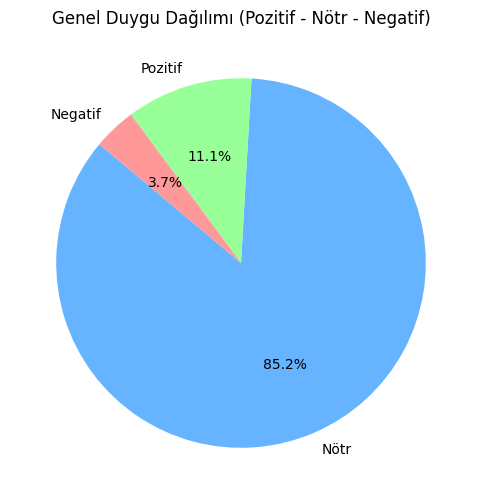


--- Pozitif Yorumlarda En Çok Geçen 10 Anlamlı Kelime ---
güzel: 1977 kez
iyi: 1930 kez
araç: 829 kez
togg: 632 kez
olmuş: 435 kez
şarj: 340 kez
harika: 326 kez
tesla: 321 kez
olur: 274 kez
sağlık: 249 kez

--- Negatif Yorumlarda En Çok Geçen 10 Anlamlı Kelime ---
pahalı: 463 kez
sorun: 382 kez
araç: 344 kez
kötü: 313 kez
şarj: 285 kez
çöp: 237 kez
togg: 153 kez
menzil: 134 kez
tesla: 126 kez
alınmaz: 115 kez

--- Nötr Yorumlarda En Çok Geçen 10 Anlamlı Kelime ---
togg: 3099 kez
araç: 2723 kez
tesla: 2117 kez
şarj: 1607 kez
zaten: 920 kez
olur: 879 kez
aynı: 870 kez
yerli: 857 kez
olan: 823 kez
uzun: 775 kez


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

# 1. Temizlenmiş veri setimizi okuyalım
dosya_yolu = 'elektrikli_arac_temiz.csv'
df = pd.read_csv(dosya_yolu, encoding='utf-8-sig', low_memory=False)

# 2. Genişletilmiş ve güncellenmiş Stop Words listesi
genisletilmis_stop_words = set([
    've', 'bir', 'bu', 'da', 'de', 'için', 'en', 'ne', 'gibi', 'elektrikli',
    'ama', 'lakin', 'ile', 'o', 'şu', 'ben', 'sen', 'biz', 'siz', 'onlar',
    'var', 'yok', 'çok', 'daha', 'nasıl', 'neden', 'çünkü', 'olarak', 'kadar',
    'sonra', 'önce', 'zaman', 'şey', 'diye', 'birçok', 'hiç', 'tüm', 'her',
    'bile', 'abi', 'olsun', 'değil', 'bence', 'bin', 'araba', 'türkiye'
])

pozitif_kelimeler = set(['güzel', 'iyi', 'harika', 'süper', 'muhteşem', 'alınır', 'konforlu', 'başarılı', 'kaliteli', 'tavsiye'])
negatif_kelimeler = set(['pahalı', 'kötü', 'sorun', 'arıza', 'alınmaz', 'rezalet', 'berbat', 'çöp', 'yavaş', 'sikayet', 'sikayetçi'])

def duygu_analizi_yap(metin):
    if not isinstance(metin, str):
        return 'Nötr'
    kelimeler = re.findall(r'\w+', metin.lower())
    pos_count = sum(1 for k in kelimeler if k in pozitif_kelimeler)
    neg_count = sum(1 for k in kelimeler if k in negatif_kelimeler)
    
    if pos_count > neg_count:
        return 'Pozitif'
    elif neg_count > pos_count:
        return 'Negatif'
    else:
        return 'Nötr'

df['Duygu'] = df['Comment'].apply(duygu_analizi_yap)

duygu_sayilari = df['Duygu'].value_counts()

plt.figure(figsize=(8, 6))
colors = ['#66b3ff', '#99ff99', '#ff9999']
plt.pie(duygu_sayilari, labels=duygu_sayilari.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Genel Duygu Dağılımı (Pozitif - Nötr - Negatif)')
plt.show()

for duygu in ['Pozitif', 'Negatif', 'Nötr']:
    alt_kumye = df[df['Duygu'] == duygu]['Comment'].dropna()
    tum_kelimeler = []
    
    for yorum in alt_kumye:
        kelimeler = re.findall(r'\w+', str(yorum).lower())
        anlamli_kelimeler = [k for k in kelimeler if k not in genisletilmis_stop_words and len(k) > 2]
        tum_kelimeler.extend(anlamli_kelimeler)
        
    en_cok_tekrar = Counter(tum_kelimeler).most_common(10)
    print(f"\n--- {duygu} Yorumlarda En Çok Geçen 10 Anlamlı Kelime ---")
    for kelime, sayi in en_cok_tekrar:
        print(f"{kelime}: {sayi} kez")


MARKA: Togg (Toplam Yorum: 3430)
  - Nötr Oranı: %82.2
  - Pozitif Oranı: %14.5
  - Negatif Oranı: %3.3
  Pozitif Yorumlarda En Çok Geçen 5 Kelime:
    * iyi: 274 kez
    * güzel: 187 kez
    * araç: 132 kez
    * tesla: 81 kez
    * yerli: 65 kez
  Negatif Yorumlarda En Çok Geçen 5 Kelime:
    * pahalı: 45 kez
    * araç: 29 kez
    * sorun: 28 kez
    * yerli: 22 kez
    * tesla: 20 kez
  Nötr Yorumlarda En Çok Geçen 5 Kelime:
    * tesla: 345 kez
    * yerli: 295 kez
    * araç: 250 kez
    * milli: 156 kez
    * olan: 120 kez


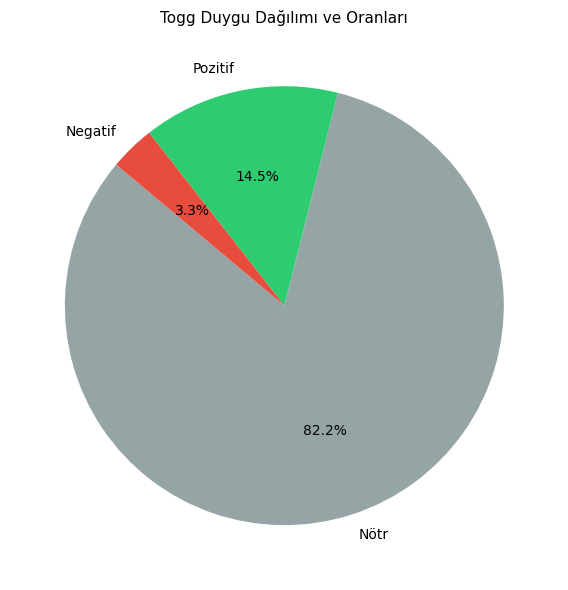


MARKA: Tesla (Toplam Yorum: 2840)
  - Nötr Oranı: %84.7
  - Pozitif Oranı: %11.3
  - Negatif Oranı: %4.0
  Pozitif Yorumlarda En Çok Geçen 5 Kelime:
    * iyi: 189 kez
    * togg: 113 kez
    * güzel: 96 kez
    * araç: 90 kez
    * model: 44 kez
  Negatif Yorumlarda En Çok Geçen 5 Kelime:
    * kötü: 35 kez
    * araç: 33 kez
    * pahalı: 32 kez
    * sorun: 31 kez
    * togg: 26 kez
  Nötr Yorumlarda En Çok Geçen 5 Kelime:
    * togg: 438 kez
    * model: 207 kez
    * araç: 194 kez
    * şarj: 119 kez
    * byd: 101 kez


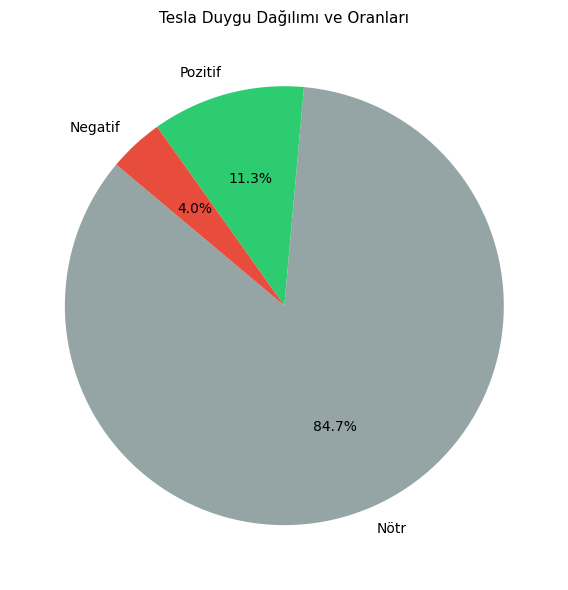


MARKA: BYD (Toplam Yorum: 754)
  - Nötr Oranı: %78.6
  - Pozitif Oranı: %15.9
  - Negatif Oranı: %5.4
  Pozitif Yorumlarda En Çok Geçen 5 Kelime:
    * iyi: 71 kez
    * güzel: 47 kez
    * araç: 47 kez
    * tesla: 28 kez
    * togg: 25 kez
  Negatif Yorumlarda En Çok Geçen 5 Kelime:
    * araç: 43 kez
    * tesla: 16 kez
    * şehir: 14 kez
    * sorun: 14 kez
    * yol: 13 kez
  Nötr Yorumlarda En Çok Geçen 5 Kelime:
    * togg: 105 kez
    * tesla: 90 kez
    * araç: 78 kez
    * seal: 52 kez
    * nin: 46 kez


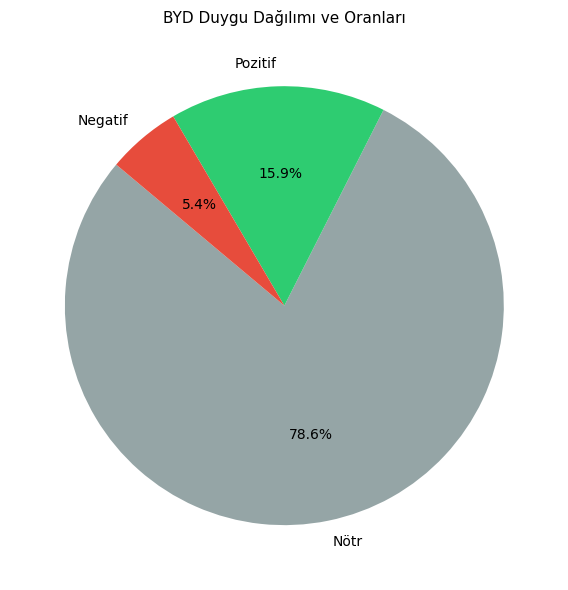


MARKA: BMW (Toplam Yorum: 376)
  - Nötr Oranı: %81.4
  - Pozitif Oranı: %14.9
  - Negatif Oranı: %3.7
  Pozitif Yorumlarda En Çok Geçen 5 Kelime:
    * iyi: 39 kez
    * güzel: 20 kez
    * araç: 17 kez
    * 100: 13 kez
    * tesla: 12 kez
  Negatif Yorumlarda En Çok Geçen 5 Kelime:
    * araç: 6 kez
    * kötü: 4 kez
    * berbat: 4 kez
    * aracı: 3 kez
    * yol: 3 kez
  Nötr Yorumlarda En Çok Geçen 5 Kelime:
    * mercedes: 68 kez
    * togg: 47 kez
    * tesla: 44 kez
    * araç: 38 kez
    * audi: 29 kez


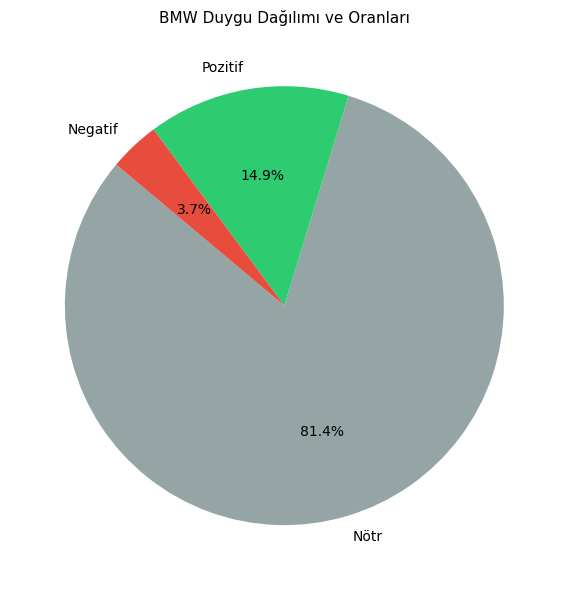


MARKA: MG (Toplam Yorum: 244)
  - Nötr Oranı: %73.0
  - Pozitif Oranı: %22.5
  - Negatif Oranı: %4.5
  Pozitif Yorumlarda En Çok Geçen 5 Kelime:
    * araç: 39 kez
    * iyi: 31 kez
    * güzel: 23 kez
    * cam: 12 kez
    * aracı: 10 kez
  Negatif Yorumlarda En Çok Geçen 5 Kelime:
    * sorun: 9 kez
    * şarj: 9 kez
    * iyi: 7 kez
    * arka: 5 kez
    * hızlı: 5 kez
  Nötr Yorumlarda En Çok Geçen 5 Kelime:
    * araç: 28 kez
    * togg: 20 kez
    * model: 15 kez
    * menzil: 14 kez
    * byd: 13 kez


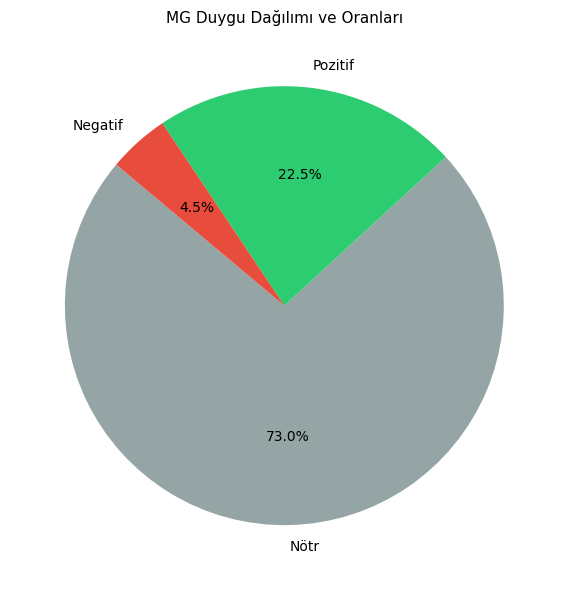


MARKA: Renault (Toplam Yorum: 99)
  - Nötr Oranı: %82.8
  - Pozitif Oranı: %12.1
  - Negatif Oranı: %5.1
  Pozitif Yorumlarda En Çok Geçen 5 Kelime:
    * güzel: 7 kez
    * araç: 5 kez
    * 000: 5 kez
    * artık: 4 kez
    * veya: 4 kez
  Negatif Yorumlarda En Çok Geçen 5 Kelime:
    * kötü: 3 kez
    * motor: 3 kez
    * vergi: 3 kez
    * olan: 2 kez
    * saat: 2 kez
  Nötr Yorumlarda En Çok Geçen 5 Kelime:
    * togg: 22 kez
    * araç: 17 kez
    * aynı: 10 kez
    * ford: 10 kez
    * fiat: 10 kez


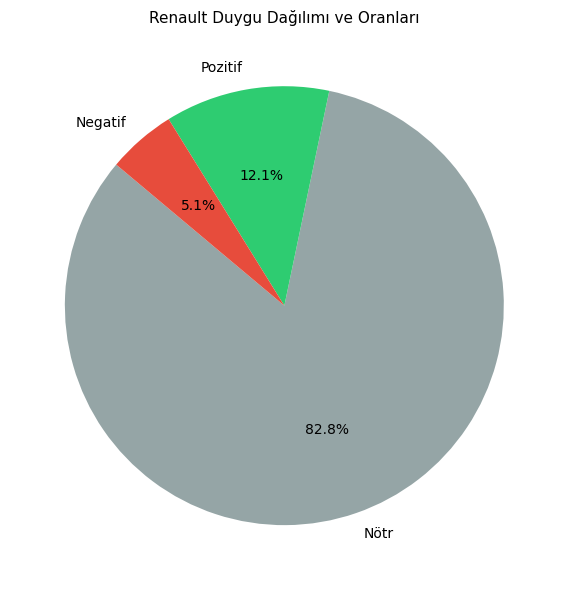


MARKA: Porsche Taycan (Toplam Yorum: 191)
  - Nötr Oranı: %83.8
  - Pozitif Oranı: %14.1
  - Negatif Oranı: %2.1
  Pozitif Yorumlarda En Çok Geçen 5 Kelime:
    * güzel: 13 kez
    * araç: 12 kez
    * iyi: 10 kez
    * tercih: 5 kez
    * olduğu: 5 kez
  Negatif Yorumlarda En Çok Geçen 5 Kelime:
    * elde: 3 kez
    * 000: 2 kez
    * pahalı: 2 kez
    * zaten: 2 kez
    * yani: 2 kez
  Nötr Yorumlarda En Çok Geçen 5 Kelime:
    * taykan: 22 kez
    * nin: 14 kez
    * şarj: 14 kez
    * araç: 12 kez
    * tesla: 10 kez


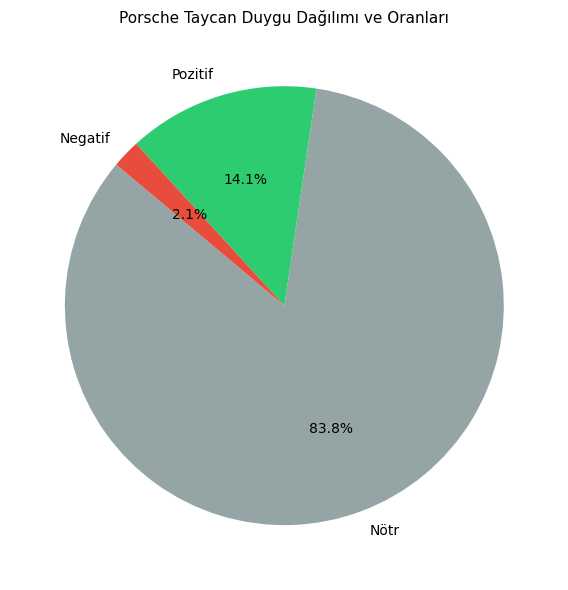


MARKA: Chery (Toplam Yorum: 300)
  - Nötr Oranı: %74.3
  - Pozitif Oranı: %20.3
  - Negatif Oranı: %5.3
  Pozitif Yorumlarda En Çok Geçen 5 Kelime:
    * güzel: 33 kez
    * iyi: 25 kez
    * pro: 15 kez
    * araç: 14 kez
    * yeni: 13 kez
  Negatif Yorumlarda En Çok Geçen 5 Kelime:
    * araç: 17 kez
    * tekrar: 11 kez
    * servise: 11 kez
    * kez: 9 kez
    * teslim: 8 kez
  Nötr Yorumlarda En Çok Geçen 5 Kelime:
    * pro: 53 kez
    * max: 35 kez
    * araç: 32 kez
    * yeni: 30 kez
    * çin: 21 kez


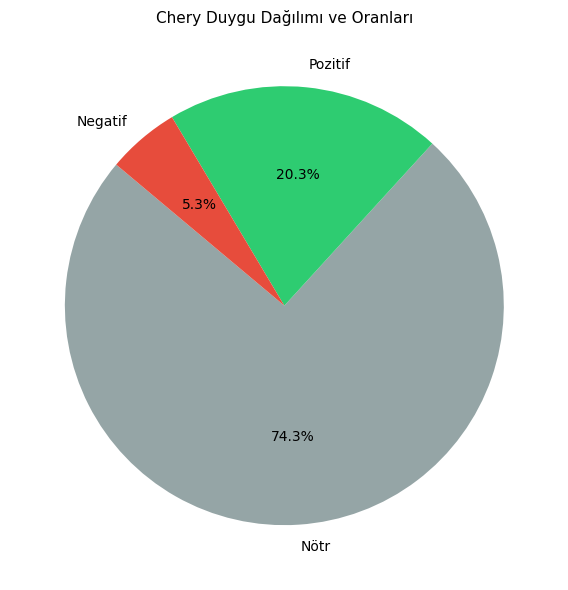


MARKA: Kia (Toplam Yorum: 297)
  - Nötr Oranı: %71.7
  - Pozitif Oranı: %23.2
  - Negatif Oranı: %5.1
  Pozitif Yorumlarda En Çok Geçen 5 Kelime:
    * araç: 39 kez
    * iyi: 32 kez
    * ev3: 32 kez
    * güzel: 26 kez
    * şarj: 22 kez
  Negatif Yorumlarda En Çok Geçen 5 Kelime:
    * araç: 14 kez
    * menzil: 11 kez
    * uzun: 10 kez
    * menzili: 8 kez
    * yani: 7 kez
  Nötr Yorumlarda En Çok Geçen 5 Kelime:
    * ev3: 56 kez
    * tesla: 39 kez
    * hyundai: 34 kez
    * menzil: 32 kez
    * ev6: 29 kez


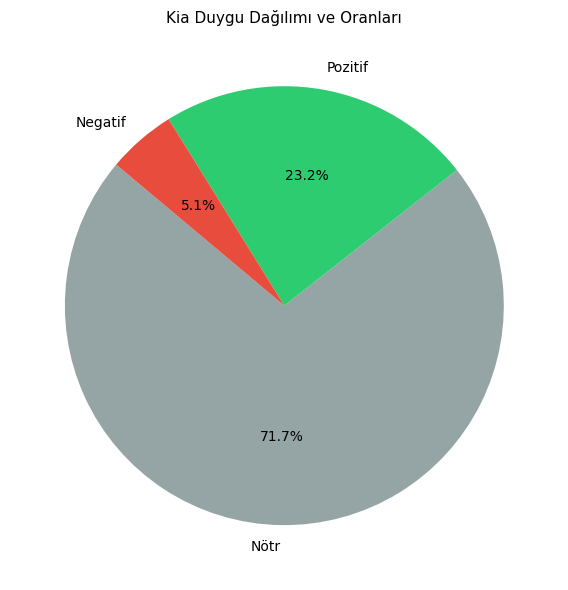


MARKA: Hyundai (Toplam Yorum: 244)
  - Nötr Oranı: %75.0
  - Pozitif Oranı: %20.9
  - Negatif Oranı: %4.1
  Pozitif Yorumlarda En Çok Geçen 5 Kelime:
    * iyi: 25 kez
    * şarj: 23 kez
    * güzel: 20 kez
    * kia: 19 kez
    * araç: 17 kez
  Negatif Yorumlarda En Çok Geçen 5 Kelime:
    * sorun: 5 kez
    * pahalı: 4 kez
    * almayın: 4 kez
    * lastik: 4 kez
    * dediler: 4 kez
  Nötr Yorumlarda En Çok Geçen 5 Kelime:
    * araç: 41 kez
    * kia: 37 kez
    * ioniq: 36 kez
    * tesla: 32 kez
    * şarj: 26 kez


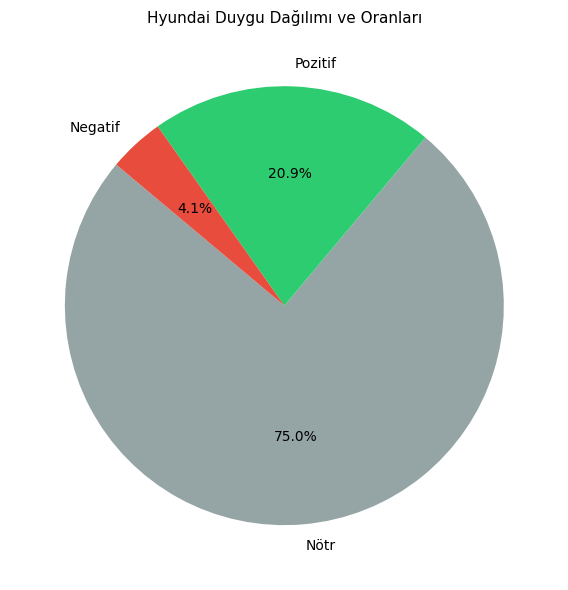

In [35]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

# 1. Veriyi okuyalım
df = pd.read_csv('elektrikli_arac_temiz.csv', encoding='utf-8-sig', low_memory=False)

# 2. Stop words ve duygu sözlükleri
genisletilmis_stop_words = set([
    've', 'bir', 'bu', 'da', 'de', 'için', 'en', 'ne', 'gibi', 'elektrikli',
    'ama', 'lakin', 'ile', 'o', 'şu', 'ben', 'sen', 'biz', 'siz', 'onlar',
    'var', 'yok', 'çok', 'daha', 'nasıl', 'neden', 'çünkü', 'olarak', 'kadar',
    'sonra', 'önce', 'zaman', 'şey', 'diye', 'birçok', 'hiç', 'tüm', 'her',
    'bile', 'abi', 'olsun', 'değil', 'bence', 'bin', 'araba', 'türkiye'
])

pozitif_kelimeler = set(['güzel', 'iyi', 'harika', 'süper', 'muhteşem', 'alınır', 'konforlu', 'başarılı', 'kaliteli', 'tavsiye'])
negatif_kelimeler = set(['pahalı', 'kötü', 'sorun', 'arıza', 'alınmaz', 'rezalet', 'berbat', 'çöp', 'yavaş', 'sikayet', 'sikayetçi'])

def duygu_analizi_yap(metin):
    if not isinstance(metin, str):
        return 'Nötr'
    kelimeler = re.findall(r'\w+', metin.lower())
    pos_count = sum(1 for k in kelimeler if k in pozitif_kelimeler)
    neg_count = sum(1 for k in kelimeler if k in negatif_kelimeler)
    
    if pos_count > neg_count:
        return 'Pozitif'
    elif neg_count > pos_count:
        return 'Negatif'
    else:
        return 'Nötr'

df['Duygu'] = df['Comment'].apply(duygu_analizi_yap)

# 3. Chery tek çatı altında toplandı, niş alt kırılımlar birleştirildi
marka_eslesmeleri = {
    'Togg': ['togg'],
    'Tesla': ['tesla'],
    'BYD': ['byd'],
    'BMW': ['bmw'],
    'MG': ['mg'],
    'Renault': ['renault'],
    'Porsche Taycan': ['porshe', 'porsche', 'taycan'],
    'Chery': ['chery', 'tiggo'],
    'Kia': ['kia'],
    'Hyundai': ['hyundai']
}

marka_sutunu = 'Marka' if 'Marka' in df.columns else 'Marka/Başlık'
df['Birlestirilmis_Metin'] = df[marka_sutunu].fillna('').astype(str).str.lower() + " " + df['Comment'].fillna('').astype(str).str.lower()

# 4. Her marka için duygu kırılımı, duyguya özel en sık geçen 5 kelime ve pasta grafiği
for marka, anahtarlar in marka_eslesmeleri.items():
    kosul = df['Birlestirilmis_Metin'].apply(lambda x: any(anahtar in x for anahtar in anahtarlar))
    marka_df = df[kosul]
    
    print(f"\n========================================")
    print(f"MARKA: {marka} (Toplam Yorum: {len(marka_df)})")
    print(f"========================================")
    
    if len(marka_df) == 0:
        print("  Bu marka için veri setinde yorum bulunamadı.")
        continue
        
    duygu_dagilimi = marka_df['Duygu'].value_counts()
    duygu_oranlari = marka_df['Duygu'].value_counts(normalize=True) * 100
    
    for duygu, oran in duygu_oranlari.items():
        print(f"  - {duygu} Oranı: %{oran:.1f}")
        
    # Pozitif, Negatif ve Nötr gruplar için ayrı ayrı en çok tekrar eden 5 kelime
    duygu_kelimeleri = {}
    for duygu_tipi in ['Pozitif', 'Negatif', 'Nötr']:
        alt_kumye = marka_df[marka_df['Duygu'] == duygu_tipi]['Comment'].dropna()
        tum_kelimeler = []
        for yorum in alt_kumye:
            kelimeler = re.findall(r'\w+', str(yorum).lower())
            anlamli_kelimeler = [k for k in kelimeler if k not in genisletilmis_stop_words and len(k) > 2 and not any(a in k for a in anahtarlar)]
            tum_kelimeler.extend(anlamli_kelimeler)
        
        en_cok_tekrar = Counter(tum_kelimeler).most_common(5)
        duygu_kelimeleri[duygu_tipi] = en_cok_tekrar
        print(f"  {duygu_tipi} Yorumlarda En Çok Geçen 5 Kelime:")
        for kelime, sayi in en_cok_tekrar:
            print(f"    * {kelime}: {sayi} kez")
        
    # Pasta Grafiği Çizimi
    plt.figure(figsize=(6, 6))
    renkler = {'Pozitif': '#2ecc71', 'Negatif': '#e74c3c', 'Nötr': '#95a5a6'}
    grafik_renkleri = [renkler.get(d, '#3498db') for d in duygu_dagilimi.index]
    
    plt.pie(duygu_dagilimi, labels=duygu_dagilimi.index, colors=grafik_renkleri, autopct='%1.1f%%', startangle=140)
    plt.title(f"{marka} Duygu Dağılımı ve Oranları", fontsize=11)
    plt.tight_layout()
    plt.show()

In [36]:
import pandas as pd
import re

# 1. Veriyi okuyalım
df = pd.read_csv('elektrikli_arac_temiz.csv', encoding='utf-8-sig', low_memory=False)

# 2. Duygu analizi fonksiyonu
pozitif_kelimeler = set(['güzel', 'iyi', 'harika', 'süper', 'muhteşem', 'alınır', 'konforlu', 'başarılı', 'kaliteli', 'tavsiye'])
negatif_kelimeler = set(['pahalı', 'kötü', 'sorun', 'arıza', 'alınmaz', 'rezalet', 'berbat', 'çöp', 'yavaş', 'sikayet', 'sikayetçi'])

def duygu_analizi_yap(metin):
    if not isinstance(metin, str):
        return 'Nötr'
    kelimeler = re.findall(r'\w+', metin.lower())
    pos_count = sum(1 for k in kelimeler if k in pozitif_kelimeler)
    neg_count = sum(1 for k in kelimeler if k in negatif_kelimeler)
    
    if pos_count > neg_count:
        return 'Pozitif'
    elif neg_count > pos_count:
        return 'Negatif'
    else:
        return 'Nötr'

df['Duygu'] = df['Comment'].apply(duygu_analizi_yap)

# 3. Marka eşleştirmeleri
marka_eslesmeleri = {
    'Togg': ['togg'],
    'Tesla': ['tesla'],
    'BYD': ['byd'],
    'BMW': ['bmw'],
    'MG': ['mg'],
    'Renault': ['renault'],
    'Porsche Taycan': ['porshe', 'porsche', 'taycan'],
    'Chery': ['chery', 'tiggo'],
    'Kia': ['kia'],
    'Hyundai': ['hyundai']
}

marka_sutunu = 'Marka' if 'Marka' in df.columns else 'Marka/Başlık'
df['Birlestirilmis_Metin'] = df[marka_sutunu].fillna('').astype(str).str.lower() + " " + df['Comment'].fillna('').astype(str).str.lower()

# 4. Özet tablo verilerini toplayalım
ozet_liste = []

for marka, anahtarlar in marka_eslesmeleri.items():
    kosul = df['Birlestirilmis_Metin'].apply(lambda x: any(anahtar in x for anahtar in anahtarlar))
    marka_df = df[kosul]
    
    toplam_yorum = len(marka_df)
    if toplam_yorum > 0:
        oranlar = marka_df['Duygu'].value_counts(normalize=True) * 100
        ozet_liste.append({
            'Marka': marka,
            'Toplam Yorum': toplam_yorum,
            'Pozitif (%)': f"%{oranlar.get('Pozitif', 0):.1f}",
            'Nötr (%)': f"%{oranlar.get('Nötr', 0):.1f}",
            'Negatif (%)': f"%{oranlar.get('Negatif', 0):.1f}"
        })

# 5. DataFrame'e çevirip ekrana basalım
ozet_df = pd.DataFrame(ozet_liste)
# Pozitif oranına göre büyükten küçüğe sıralayalım
ozet_df = ozet_df.sort_values(by='Toplam Yorum', ascending=False).reset_index(drop=True)

print("\n--- ELEKTRİKLİ ARAÇ MARKALARI ÖZET KARŞILAŞTIRMA TABLOSU ---")
display(ozet_df) # Jupyter/Kaggle için şık tablo gösterimi


--- ELEKTRİKLİ ARAÇ MARKALARI ÖZET KARŞILAŞTIRMA TABLOSU ---


,Marka,Toplam Yorum,Pozitif (%),Nötr (%),Negatif (%)
0,Togg,3430,%14.5,%82.2,%3.3
1,Tesla,2840,%11.3,%84.7,%4.0
2,BYD,754,%15.9,%78.6,%5.4
3,BMW,376,%14.9,%81.4,%3.7
4,Chery,300,%20.3,%74.3,%5.3
5,Kia,297,%23.2,%71.7,%5.1
6,Hyundai,244,%20.9,%75.0,%4.1
7,MG,244,%22.5,%73.0,%4.5
8,Porsche Taycan,191,%14.1,%83.8,%2.1
9,Renault,99,%12.1,%82.8,%5.1


In [38]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Veriyi okuyalım
df = pd.read_csv('elektrikli_arac_temiz.csv', encoding='utf-8-sig', low_memory=False)

# 2. Stop words ve duygu sözlükleri
genisletilmis_stop_words = set([
    've', 'bir', 'bu', 'da', 'de', 'için', 'en', 'ne', 'gibi', 'elektrikli',
    'ama', 'lakin', 'ile', 'o', 'şu', 'ben', 'sen', 'biz', 'siz', 'onlar',
    'var', 'yok', 'çok', 'daha', 'nasıl', 'neden', 'çünkü', 'olarak', 'kadar',
    'sonra', 'önce', 'zaman', 'şey', 'diye', 'birçok', 'hiç', 'tüm', 'her',
    'bile', 'abi', 'olsun', 'değil', 'bence', 'bin', 'araba', 'türkiye'
])

pozitif_kelimeler = set(['güzel', 'iyi', 'harika', 'süper', 'muhteşem', 'alınır', 'konforlu', 'başarılı', 'kaliteli', 'tavsiye'])
negatif_kelimeler = set(['pahalı', 'kötü', 'sorun', 'arıza', 'alınmaz', 'rezalet', 'berbat', 'çöp', 'yavaş', 'sikayet', 'sikayetçi'])

def duygu_analizi_yap(metin):
    if not isinstance(metin, str):
        return 'Nötr'
    kelimeler = re.findall(r'\w+', metin.lower())
    pos_count = sum(1 for k in kelimeler if k in pozitif_kelimeler)
    neg_count = sum(1 for k in kelimeler if k in negatif_kelimeler)
    
    if pos_count > neg_count:
        return 'Pozitif'
    elif neg_count > pos_count:
        return 'Negatif'
    else:
        return 'Nötr'

df['Duygu'] = df['Comment'].apply(duygu_analizi_yap)

# 3. Marka eşleştirmeleri
marka_eslesmeleri = {
    'Togg': ['togg'],
    'Tesla': ['tesla'],
    'BYD': ['byd'],
    'BMW': ['bmw'],
    'MG': ['mg'],
    'Renault': ['renault'],
    'Porsche Taycan': ['porshe', 'porsche', 'taycan'],
    'Chery': ['chery', 'tiggo'],
    'Kia': ['kia'],
    'Hyundai': ['hyundai']
}

marka_sutunu = 'Marka' if 'Marka' in df.columns else 'Marka/Başlık'
df['Birlestirilmis_Metin'] = df[marka_sutunu].fillna('').astype(str).str.lower() + " " + df['Comment'].fillna('').astype(str).str.lower()

# 4. TF-IDF Bigram Analiz Fonksiyonu
def tfidf_bigram_analizi(metinler, stop_words, n=3):
    if len(metinler) < 2:
        return []
    # ngram_range=(2,2) ile ikili kombinasyonlara bakıp TF-IDF skoru hesaplıyoruz
    vectorizer = TfidfVectorizer(ngram_range=(2, 2), stop_words=list(stop_words), max_features=1000, min_df=2)
    try:
        X = vectorizer.fit_transform(metinler.astype(str))
        scores = X.mean(axis=0).A1
        tfidf_pairs = [(word, scores[idx]) for word, idx in vectorizer.vocabulary_.items()]
        tfidf_pairs = sorted(tfidf_pairs, key=lambda x: x[1], reverse=True)
        return tfidf_pairs[:n]
    except ValueError:
        return []

# 5. Her marka ve duygu kırılımı için en ayırt edici ikilileri basalım
for marka, anahtarlar in marka_eslesmeleri.items():
    kosul = df['Birlestirilmis_Metin'].apply(lambda x: any(anahtar in x for anahtar in anahtarlar))
    marka_df = df[kosul]
    
    print(f"\n========================================")
    print(f"MARKA: {marka} (Toplam Yorum: {len(marka_df)})")
    print(f"========================================")
    
    if len(marka_df) == 0:
        print("  Bu marka için veri setinde yorum bulunamadı.")
        continue
        
    for duygu_tipi in ['Pozitif', 'Negatif', 'Nötr']:
        alt_kumye = marka_df[marka_df['Duygu'] == duygu_tipi]['Comment'].dropna()
        en_ayiirici_ikililer = tfidf_bigram_analizi(alt_kumye, genisletilmis_stop_words, n=3)
        
        print(f"  {duygu_tipi} En Ayırt Edici TF-IDF İkilileri:")
        if en_ayiirici_ikililer:
            for ikili, skor in en_ayiirici_ikililer:
                print(f"    * \"{ikili}\": (Skor: {skor:.4f})")
        else:
            print("    * Yeterli veri bulunamadı.")


MARKA: Togg (Toplam Yorum: 3430)
  Pozitif En Ayırt Edici TF-IDF İkilileri:
    * "togg un": (Skor: 0.0313)
    * "togg iyi": (Skor: 0.0290)
    * "togg güzel": (Skor: 0.0266)
  Negatif En Ayırt Edici TF-IDF İkilileri:
    * "togg un": (Skor: 0.0603)
    * "yerli milli": (Skor: 0.0286)
    * "tesla togg": (Skor: 0.0273)
  Nötr En Ayırt Edici TF-IDF İkilileri:
    * "togg un": (Skor: 0.0396)
    * "yerli milli": (Skor: 0.0128)
    * "togg dan": (Skor: 0.0123)

MARKA: Tesla (Toplam Yorum: 2840)
  Pozitif En Ayırt Edici TF-IDF İkilileri:
    * "tesla iyi": (Skor: 0.0462)
    * "tesla model": (Skor: 0.0426)
    * "tesla ya": (Skor: 0.0222)
  Negatif En Ayırt Edici TF-IDF İkilileri:
    * "tesla çöp": (Skor: 0.0435)
    * "tesla byd": (Skor: 0.0381)
    * "tesla model": (Skor: 0.0351)
  Nötr En Ayırt Edici TF-IDF İkilileri:
    * "tesla model": (Skor: 0.0301)
    * "tesla nın": (Skor: 0.0154)
    * "tesla ya": (Skor: 0.0119)

MARKA: BYD (Toplam Yorum: 754)
  Pozitif En Ayırt Edici TF-IDF İ